In [ ]:
import kagglehub
import polars as pl
import numpy as np
import os
import gc

# ============================================================
# PART 1: DATA LOADING AND INITIAL EXTRACTION
# ============================================================

# Download dataset from Kaggle
path = kagglehub.dataset_download("dasgroup/rba-dataset")
csv_path = os.path.join(path, "rba-dataset.csv")

# Selected features and target label
FEATURE_COLS = [
    "User ID",
    "ASN",
    "IP Address",
    "Round-Trip Time [ms]"
]
TARGET_COL = "Is Account Takeover"

# Load only required columns (memory efficient)
df = pl.read_csv(
    csv_path,
    columns=FEATURE_COLS + [TARGET_COL]
)

print(f"Dataset shape: {df.shape}")

# Separate classes
positives = df.filter(pl.col(TARGET_COL) == True)
negatives = df.filter(pl.col(TARGET_COL) == False)

print(f"Legitimate samples : {len(negatives):,}")
print(f"Takeover samples   : {len(positives):,}")
print(f"Imbalance ratio    : 1 : {len(negatives)//len(positives):,}")

# Save raw splits
positives.write_parquet("positives_raw.parquet")
negatives.sample(
    n=min(200_000, len(negatives)),
    seed=42
).write_parquet("negatives_raw.parquet")

# Free memory
del df, negatives
gc.collect()

Using Colab cache for faster access to the 'rba-dataset' dataset.
Dataset shape: (31269264, 5)
Legitimate samples : 31,269,123
Takeover samples   : 141
Imbalance ratio    : 1 : 221,766


166

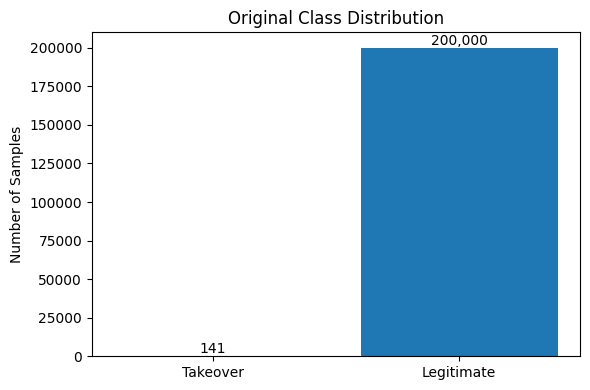

In [ ]:
# ============================================================
# PLOT 1: Original Class Distribution
# ============================================================

import matplotlib.pyplot as plt
import polars as pl

# Reload raw splits (since earlier variables were deleted)
positives_plot = pl.read_parquet("positives_raw.parquet")
negatives_plot = pl.read_parquet("negatives_raw.parquet")

counts = [len(positives_plot), len(negatives_plot)]
labels = ["Takeover", "Legitimate"]

plt.figure(figsize=(6,4))
bars = plt.bar(labels, counts)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{int(height):,}",
             ha='center',
             va='bottom')

plt.title("Original Class Distribution")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

In [ ]:
import polars as pl
import numpy as np
import gc

# ============================================================
# PART 2: DATA CLEANING AND FEATURE ENGINEERING
# ============================================================

# Load previously saved raw splits
positives = pl.read_parquet("positives_raw.parquet")
negatives = pl.read_parquet("negatives_raw.parquet")

def preprocess_data(df: pl.DataFrame) -> pl.DataFrame:
    """
    Perform data cleaning and feature engineering:
    - Handle missing values
    - Log-transform RTT
    - Encode categorical identifiers
    - Cast target to integer
    """

    # Handle missing values
    rtt_median = df["Round-Trip Time [ms]"].median() or 0.0

    df = df.with_columns([
        pl.col("Round-Trip Time [ms]").fill_null(rtt_median),
        pl.col("ASN").fill_null("UNKNOWN_ASN"),
        pl.col("User ID").fill_null("UNKNOWN_USER"),
        pl.col("IP Address").fill_null("0.0.0.0")
    ])

    # Log transformation of RTT to stabilize scale
    df = df.with_columns([
        (pl.col("Round-Trip Time [ms]") + 1).log().alias("RTT_log")
    ])

    # Encode high-cardinality identifiers
    df = df.with_columns([
        (pl.col("User ID").hash() % 2147483647).cast(pl.Int32).alias("User_ID_encoded"),
        (pl.col("IP Address").hash() % 2147483647).cast(pl.Int32).alias("IP_encoded"),
        pl.col("ASN").cast(pl.Categorical).to_physical().alias("ASN_encoded"),
        pl.col("Is Account Takeover").cast(pl.Int8)
    ])

    return df


# Apply preprocessing
positives_clean = preprocess_data(positives)
negatives_clean = preprocess_data(negatives)

# Save cleaned datasets
positives_clean.write_parquet("positives_clean.parquet")
negatives_clean.write_parquet("negatives_clean.parquet")

# Free memory
del positives, negatives, positives_clean, negatives_clean
gc.collect()

2473

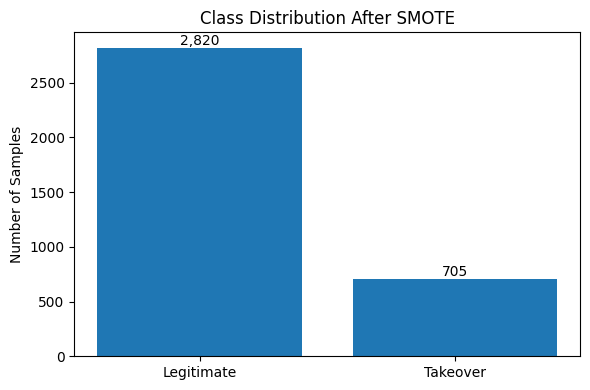

2784

In [ ]:
import polars as pl
import numpy as np
from imblearn.over_sampling import SMOTE
import gc

# ============================================================
# PART 3: CLASS BALANCING USING UNDERSAMPLING + SMOTE
# ============================================================

# Load cleaned datasets
positives = pl.read_parquet("positives_clean.parquet")
negatives = pl.read_parquet("negatives_clean.parquet")

FEATURE_COLS = [
    "User_ID_encoded",
    "ASN_encoded",
    "IP_encoded",
    "RTT_log"
]

# ------------------------------------------------------------
# Step 1: Undersample majority class (Legitimate sessions)
# ------------------------------------------------------------

target_negatives = len(positives) * 20
negatives_undersampled = negatives.sample(
    n=min(target_negatives, len(negatives)),
    seed=42
)

# Combine minority + undersampled majority
combined = pl.concat([positives, negatives_undersampled])

X = combined.select(FEATURE_COLS).to_numpy()
y = combined.select("Is Account Takeover").to_numpy().flatten()

# Ensure numerical stability
X = np.nan_to_num(X, nan=0.0, posinf=1e10, neginf=-1e10)

# ------------------------------------------------------------
# Step 2: Apply SMOTE to generate synthetic minority samples
# ------------------------------------------------------------

k_neighbors = min(5, sum(y == 1) - 1)

smote = SMOTE(
    sampling_strategy=0.25,   # ~20% minority class
    random_state=42,
    k_neighbors=k_neighbors
)

X_balanced, y_balanced = smote.fit_resample(X, y)

# ------------------------------------------------------------
# Save balanced dataset
# ------------------------------------------------------------

np.save("X_balanced.npy", X_balanced)
np.save("y_balanced.npy", y_balanced)
np.save("feature_names.npy", np.array(FEATURE_COLS))

balanced_df = pl.DataFrame(X_balanced, schema=FEATURE_COLS)
balanced_df = balanced_df.with_columns(
    pl.Series("Is Account Takeover", y_balanced)
)
balanced_df.write_parquet("balanced_dataset.parquet")

# ============================================================
# PLOT 2: Class Distribution After SMOTE
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

counts_after = [
    np.sum(y_balanced == 0),
    np.sum(y_balanced == 1)
]

labels = ["Legitimate", "Takeover"]

plt.figure(figsize=(6,4))
bars = plt.bar(labels, counts_after)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{int(height):,}",
             ha='center',
             va='bottom')

plt.title("Class Distribution After SMOTE")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

# Free memory
del X, y, combined, positives, negatives, negatives_undersampled
gc.collect()

In [ ]:
# ============================================================
# BLOCK 4: GRAPH CONSTRUCTION AND DATA SPLITTING
# ============================================================

!pip install torch_geometric -q

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import defaultdict

# ------------------------------------------------------------
# Load balanced dataset
# ------------------------------------------------------------

X = np.load("X_balanced.npy")
y = np.load("y_balanced.npy")

X_raw = X.copy()

# Standardize numerical features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ------------------------------------------------------------
# Graph Construction (Entity-based connectivity)
# ------------------------------------------------------------

edges = []
edge_weights =[]

user_groups = defaultdict(list)
ip_groups   = defaultdict(list)
asn_groups  = defaultdict(list)

# Group nodes by shared identifiers
for i, row in enumerate(X_raw):
    user_groups[int(row[0])].append(i)
    asn_groups[int(row[1])].append(i)
    ip_groups[int(row[2])].append(i)

def connect(groups, weight, max_conn=15):
    """
    Connect nodes within each entity group.
    max_conn limits quadratic explosion for large groups.
    """
    for nodes in groups.values():
        nodes = nodes[:max_conn]
        for i in range(len(nodes)):
            for j in range(i + 1, len(nodes)):
                edges.append([nodes[i], nodes[j]])
                edges.append([nodes[j], nodes[i]])
                edge_weights.append(weight)
                edge_weights.append(weight)

# Entity-based edges
connect(user_groups, weight=1.0)
connect(ip_groups,   weight=0.7)
connect(asn_groups,  weight=0.4)

edge_index = torch.tensor(edges, dtype=torch.long).t()

# ------------------------------------------------------------
# Add Degree as Structural Feature
# ------------------------------------------------------------

degree = np.zeros(len(X))
for e in edge_index[0].numpy():
    degree[e] += 1

degree = degree / (degree.max() + 1e-6)
X = np.column_stack([X, degree])

# Create PyG Data object
data = Data(
    x=torch.tensor(X, dtype=torch.float32),
    y=torch.tensor(y, dtype=torch.long),
    edge_index=edge_index
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data = data.to(device)

# ------------------------------------------------------------
# Train / Validation / Test Split (Stratified)
# ------------------------------------------------------------

idx = np.arange(data.num_nodes)

# 75% Train+Val, 25% Test
train_idx_full, test_idx = train_test_split(
    idx,
    test_size=0.25,
    stratify=y,
    random_state=21
)

# 85% of Train+Val → Train, 15% → Validation
train_idx, val_idx = train_test_split(
    train_idx_full,
    test_size=0.15,
    stratify=y[train_idx_full],
    random_state=21
)

train_mask = torch.zeros(data.num_nodes, dtype=torch.bool, device=device)
val_mask   = torch.zeros(data.num_nodes, dtype=torch.bool, device=device)
test_mask  = torch.zeros(data.num_nodes, dtype=torch.bool, device=device)

train_mask[train_idx] = True
val_mask[val_idx]     = True
test_mask[test_idx]   = True

In [ ]:
# ============================================================
# BLOCK 5: MODEL DEFINITION AND TRAINING
# ============================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    average_precision_score
)

# ------------------------------------------------------------
# Model Architecture
# ------------------------------------------------------------

class HighPrecisionGNN(nn.Module):
    """
    Hybrid GATv2 + Transformer model for node classification.
    """

    def __init__(self, in_dim):
        super().__init__()

        self.gnn1 = GATv2Conv(in_dim, 64, heads=4, dropout=0.3)
        self.gnn2 = GATv2Conv(64 * 4, 64, heads=2, dropout=0.3)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=128,
            nhead=4,
            dim_feedforward=256,
            dropout=0.3,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=1
        )

        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(128, 2)

    def forward(self, x, edge_index):
        x = F.elu(self.gnn1(x, edge_index))
        x = F.elu(self.gnn2(x, edge_index))

        x_trans = self.transformer(x.unsqueeze(1)).squeeze(1)
        x = x + x_trans   # residual connection
        x = self.dropout(x)

        return self.classifier(x)


# ------------------------------------------------------------
# Training Setup
# ------------------------------------------------------------

model = HighPrecisionGNN(data.num_node_features).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0008)

best_f1 = 0.0
patience = 20
counter = 0

# ------------------------------------------------------------
# Training Loop with Early Stopping
# ------------------------------------------------------------
train_losses = []
for epoch in range(1, 101):

    model.train()
    optimizer.zero_grad()

    train_edge_mask = train_mask[data.edge_index[0]] & train_mask[data.edge_index[1]]
    train_edge_index = data.edge_index[:, train_edge_mask]

    out = model(data.x, train_edge_index)
    loss = criterion(out[train_mask], data.y[train_mask])

    loss.backward()
    train_losses.append(loss.item())
    optimizer.step()

    # ----- Validation -----
    model.eval()
    with torch.no_grad():
        val_logits = model(data.x, train_edge_index)
        val_probs = torch.softmax(val_logits, dim=1)[:, 1][val_mask]
        val_preds = (val_probs > 0.5).long()
        val_f1 = f1_score(data.y[val_mask].cpu(), val_preds.cpu())

    model.train()

    if val_f1 > best_f1:
        best_f1 = val_f1
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f} | Val F1: {val_f1:.4f}")


# ------------------------------------------------------------
# Training Metrics
# ------------------------------------------------------------

model.eval()
with torch.no_grad():

    train_edge_mask = train_mask[data.edge_index[0]] & train_mask[data.edge_index[1]]
    train_edge_index = data.edge_index[:, train_edge_mask]

    train_logits = model(data.x, train_edge_index)
    train_probs_all = torch.softmax(train_logits, dim=1)[:, 1]

    train_probs = train_probs_all[train_mask]
    train_preds = (train_probs > 0.5).long()

    train_true = data.y[train_mask].cpu().numpy()
    train_preds = train_preds.cpu().numpy()
    train_probs = train_probs.cpu().numpy()

print("\nTRAIN METRICS")
print("Precision:", precision_score(train_true, train_preds))
print("Recall   :", recall_score(train_true, train_preds))
print("F1-score :", f1_score(train_true, train_preds))
print("MCC      :", matthews_corrcoef(train_true, train_preds))
print("PR-AUC   :", average_precision_score(train_true, train_probs))

torch.save(model.state_dict(), "best_model.pth")
print("Model saved.")


Epoch 010 | Loss: 0.3546 | Val F1: 0.9693
Epoch 020 | Loss: 0.2572 | Val F1: 0.9634
Early stopping triggered

TRAIN METRICS
Precision: 0.9036402569593148
Recall   : 0.9377777777777778
F1-score : 0.920392584514722
MCC      : 0.9002260465239725
PR-AUC   : 0.8869223119672531
Model saved.


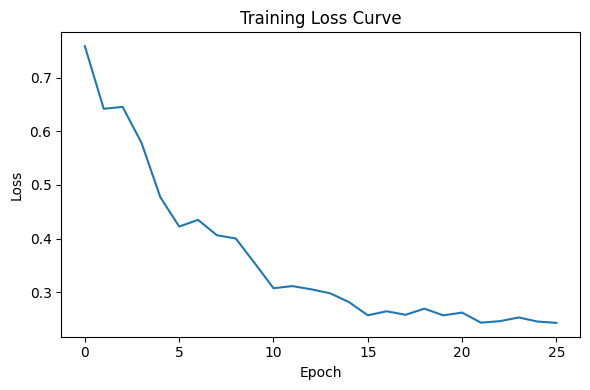

In [ ]:
# ============================================================
# PLOT 3: Training Loss Curve
# ============================================================

plt.figure(figsize=(6,4))
plt.plot(train_losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()


Optimal Threshold (Validation): 0.61

TEST METRICS
Precision : 0.8578947368421053
Recall    : 0.9261363636363636
F1-score  : 0.8907103825136612
MCC       : 0.8631560928162513
PR-AUC    : 0.8239586019786034

Confusion Matrix:


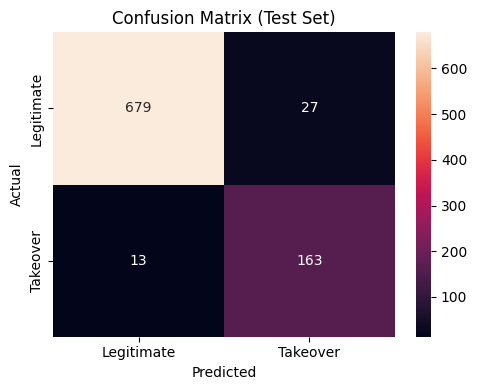

In [ ]:
# ============================================================
# BLOCK 6: TEST SET EVALUATION
# ============================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    average_precision_score,

)

# ------------------------------------------------------------
# Load Best Model
# ------------------------------------------------------------

model = HighPrecisionGNN(data.num_node_features).to(device)
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

# ------------------------------------------------------------
# Determine Optimal Threshold Using Validation Set
# ------------------------------------------------------------

with torch.no_grad():
    val_edge_mask = val_mask[data.edge_index[0]] & val_mask[data.edge_index[1]]
    val_edge_index = data.edge_index[:, val_edge_mask]

    val_logits = model(data.x, val_edge_index)
    val_probs_all = torch.softmax(val_logits, dim=1)[:, 1]

val_true = data.y[val_mask].cpu().numpy()
val_probs = val_probs_all[val_mask].cpu().numpy()

best_threshold = 0.5
best_f1 = 0.0

for t in np.arange(0.1, 0.9, 0.01):
    preds = (val_probs > t).astype(int)
    f1 = f1_score(val_true, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"\nOptimal Threshold (Validation): {best_threshold:.2f}")

# ------------------------------------------------------------
# Test Set Evaluation
# ------------------------------------------------------------

with torch.no_grad():
    test_edge_mask = test_mask[data.edge_index[0]] & test_mask[data.edge_index[1]]
    test_edge_index = data.edge_index[:, test_edge_mask]

    test_logits = model(data.x, test_edge_index)
    test_probs_all = torch.softmax(test_logits, dim=1)[:, 1]

true = data.y[test_mask].cpu().numpy()
test_probs = test_probs_all[test_mask].cpu().numpy()

final_preds = (test_probs > best_threshold).astype(int)

precision = precision_score(true, final_preds)
recall = recall_score(true, final_preds)
f1 = f1_score(true, final_preds)
mcc = matthews_corrcoef(true, final_preds)
pr_auc = average_precision_score(true, test_probs)


print("\nTEST METRICS")
print("Precision :", precision)
print("Recall    :", recall)
print("F1-score  :", f1)
print("MCC       :", mcc)
print("PR-AUC    :", pr_auc)


print("\nConfusion Matrix:")
# ============================================================
# PLOT 4: Confusion Matrix
# ============================================================

import seaborn as sns

cm = confusion_matrix(true, final_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Legitimate","Takeover"],
            yticklabels=["Legitimate","Takeover"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

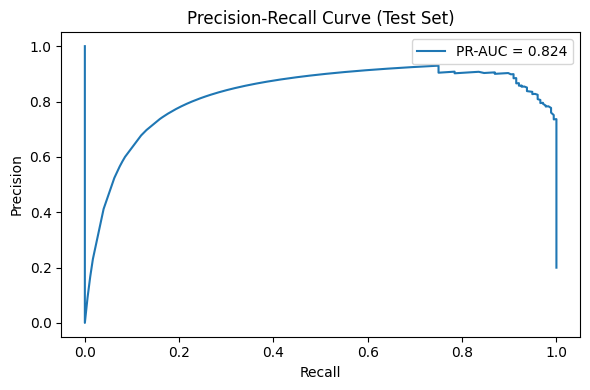

In [ ]:
# ============================================================
# PLOT 5: Precision-Recall Curve
# ============================================================

from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, _ = precision_recall_curve(true, test_probs)

plt.figure(figsize=(6,4))
plt.plot(recall_vals, precision_vals, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# SAVE IMPORTANT FILES TO GOOGLE DRIVE (RUN ONLY ONCE)
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import shutil

shutil.copy("X_balanced.npy", "/content/drive/MyDrive/X_balanced.npy")
shutil.copy("y_balanced.npy", "/content/drive/MyDrive/y_balanced.npy")
shutil.copy("best_model.pth", "/content/drive/MyDrive/best_model.pth")
np.save("train_losses.npy", np.array(train_losses))
shutil.copy("train_losses.npy", "/content/drive/MyDrive/train_losses.npy")

print("✅ Files successfully saved to Google Drive.")

Mounted at /content/drive
✅ Files successfully saved to Google Drive.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np

X = np.load("/content/drive/MyDrive/X_balanced.npy")
y = np.load("/content/drive/MyDrive/y_balanced.npy")
train_losses = np.load("/content/drive/MyDrive/train_losses.npy")

In [ ]:
 # ============================================================
# BLOCK 4: GRAPH CONSTRUCTION AND DATA SPLITTING
# ============================================================

!pip install torch_geometric -q

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import defaultdict

# ------------------------------------------------------------
# Load balanced dataset
# ------------------------------------------------------------

# X = np.load("X_balanced.npy") # X and y are already loaded into memory from Google Drive by cell ZkfPMWTmJ1pM
# y = np.load("y_balanced.npy")

X_raw = X.copy()

# Standardize numerical features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ------------------------------------------------------------
# Graph Construction (Entity-based connectivity)
# ------------------------------------------------------------

edges = []
edge_weights =[]

user_groups = defaultdict(list)
ip_groups   = defaultdict(list)
asn_groups  = defaultdict(list)

# Group nodes by shared identifiers
for i, row in enumerate(X_raw):
    user_groups[int(row[0])].append(i)
    asn_groups[int(row[1])].append(i)
    ip_groups[int(row[2])].append(i)

def connect(groups, weight, max_conn=15):
    """
    Connect nodes within each entity group.
    max_conn limits quadratic explosion for large groups.
    """
    for nodes in groups.values():
        nodes = nodes[:max_conn]
        for i in range(len(nodes)):
            for j in range(i + 1, len(nodes)):
                edges.append([nodes[i], nodes[j]])
                edges.append([nodes[j], nodes[i]])
                edge_weights.append(weight)
                edge_weights.append(weight)

# Entity-based edges
connect(user_groups, weight=1.0)
connect(ip_groups,   weight=0.7)
connect(asn_groups,  weight=0.4)

edge_index = torch.tensor(edges, dtype=torch.long).t()

# ------------------------------------------------------------
# Add Degree as Structural Feature
# ------------------------------------------------------------

degree = np.zeros(len(X))
for e in edge_index[0].numpy():
    degree[e] += 1

degree = degree / (degree.max() + 1e-6)
X = np.column_stack([X, degree])

# Create PyG Data object
data = Data(
    x=torch.tensor(X, dtype=torch.float32),
    y=torch.tensor(y, dtype=torch.long),
    edge_index=edge_index
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data = data.to(device)

# ------------------------------------------------------------
# Train / Validation / Test Split (Stratified)
# ------------------------------------------------------------

idx = np.arange(data.num_nodes)

# 75% Train+Val, 25% Test
train_idx_full, test_idx = train_test_split(
    idx,
    test_size=0.25,
    stratify=y,
    random_state=21
)

# 85% of Train+Val → Train, 15% → Validation
train_idx, val_idx = train_test_split(
    train_idx_full,
    test_size=0.15,
    stratify=y[train_idx_full],
    random_state=21
)

train_mask = torch.zeros(data.num_nodes, dtype=torch.bool, device=device)
val_mask   = torch.zeros(data.num_nodes, dtype=torch.bool, device=device)
test_mask  = torch.zeros(data.num_nodes, dtype=torch.bool, device=device)

train_mask[train_idx] = True
val_mask[val_idx]     = True
test_mask[test_idx]   = True


In [ ]:
class HighPrecisionGNN(nn.Module):
    """
    Hybrid GATv2 + Transformer model for node classification.
    """

    def __init__(self, in_dim):
        super().__init__()

        self.gnn1 = GATv2Conv(in_dim, 64, heads=4, dropout=0.3)
        self.gnn2 = GATv2Conv(64 * 4, 64, heads=2, dropout=0.3)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=128,
            nhead=4,
            dim_feedforward=256,
            dropout=0.3,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=1
        )

        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(128, 2)

    def forward(self, x, edge_index):
        x = F.elu(self.gnn1(x, edge_index))
        x = F.elu(self.gnn2(x, edge_index))

        x_trans = self.transformer(x.unsqueeze(1)).squeeze(1)
        x = x + x_trans   # residual connection
        x = self.dropout(x)

        return self.classifier(x)

In [ ]:
model = HighPrecisionGNN(data.num_node_features).to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/best_model.pth"))
model.eval()

HighPrecisionGNN(
  (gnn1): GATv2Conv(5, 64, heads=4)
  (gnn2): GATv2Conv(256, 64, heads=2)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=128, out_features=2, bias=True)
)


Optimal Threshold (Validation): 0.61

TEST METRICS
Precision : 0.8578947368421053
Recall    : 0.9261363636363636
F1-score  : 0.8907103825136612
MCC       : 0.8631560928162513
PR-AUC    : 0.8239586019786034

Confusion Matrix:


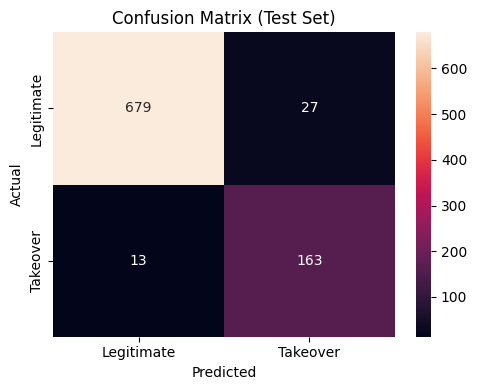

In [ ]:
# ============================================================
# BLOCK 6: TEST SET EVALUATION
# ============================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    average_precision_score
)

import matplotlib.pyplot as plt # Added this import

# ------------------------------------------------------------
# Load Best Model
# ------------------------------------------------------------

model = HighPrecisionGNN(data.num_node_features).to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/best_model.pth"))
model.eval()

# ------------------------------------------------------------
# Determine Optimal Threshold Using Validation Set
# ------------------------------------------------------------

with torch.no_grad():
    val_edge_mask = val_mask[data.edge_index[0]] & val_mask[data.edge_index[1]]
    val_edge_index = data.edge_index[:, val_edge_mask]

    val_logits = model(data.x, val_edge_index)
    val_probs_all = torch.softmax(val_logits, dim=1)[:, 1]

val_true = data.y[val_mask].cpu().numpy()
val_probs = val_probs_all[val_mask].cpu().numpy()

best_threshold = 0.5
best_f1 = 0.0

for t in np.arange(0.1, 0.9, 0.01):
    preds = (val_probs > t).astype(int)
    f1 = f1_score(val_true, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"\nOptimal Threshold (Validation): {best_threshold:.2f}")

# ------------------------------------------------------------
# Test Set Evaluation
# ------------------------------------------------------------

with torch.no_grad():
    test_edge_mask = test_mask[data.edge_index[0]] & test_mask[data.edge_index[1]]
    test_edge_index = data.edge_index[:, test_edge_mask]

    test_logits = model(data.x, test_edge_index)
    test_probs_all = torch.softmax(test_logits, dim=1)[:, 1]

true = data.y[test_mask].cpu().numpy()
test_probs = test_probs_all[test_mask].cpu().numpy()

final_preds = (test_probs > best_threshold).astype(int)

precision = precision_score(true, final_preds)
recall = recall_score(true, final_preds)
f1 = f1_score(true, final_preds)
mcc = matthews_corrcoef(true, final_preds)
pr_auc = average_precision_score(true, test_probs)


print("\nTEST METRICS")
print("Precision :", precision)
print("Recall    :", recall)
print("F1-score  :", f1)
print("MCC       :", mcc)
print("PR-AUC    :", pr_auc)


print("\nConfusion Matrix:")
# ============================================================
# PLOT 4: Confusion Matrix
# ============================================================

import seaborn as sns

cm = confusion_matrix(true, final_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Legitimate","Takeover"],
            yticklabels=["Legitimate","Takeover"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

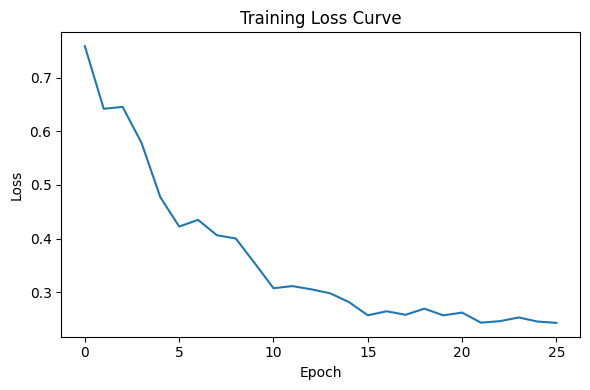

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(train_losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

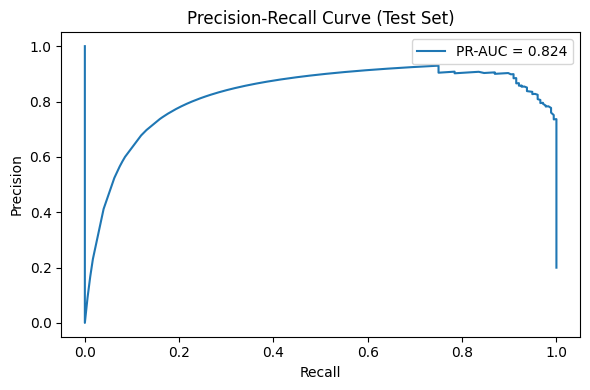

In [ ]:
# ============================================================
# PLOT 5: Precision-Recall Curve
# ============================================================

from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, _ = precision_recall_curve(true, test_probs)

plt.figure(figsize=(6,4))
plt.plot(recall_vals, precision_vals, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()